# GBPUSD V. EURUSD

### GOOGLE DRIVE

In [21]:
from google.colab import drive
import sys, os, shutil, subprocess

drive.mount('/content/drive')

REPO_ROOT  = '/content/stk-mat2011'
REPO_DATA  = f'{REPO_ROOT}/code/data/processed'
DRIVE_DATA = '/content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed'

# 1. Clone (or pull if already cloned this session)
if not os.path.isdir(REPO_ROOT):
    subprocess.run(['git', 'clone', 'https://github.com/egil10/stk-mat2011.git', REPO_ROOT], check=True)
else:
    subprocess.run(['git', '-C', REPO_ROOT, 'pull'], check=True)

# 2. Replace empty data dir from clone with symlink to Drive
if os.path.isdir(REPO_DATA) and not os.path.islink(REPO_DATA):
    shutil.rmtree(REPO_DATA)
if os.path.islink(REPO_DATA) and not os.path.exists(REPO_DATA):
    os.unlink(REPO_DATA)  # broken symlink
if not os.path.islink(REPO_DATA):
    os.symlink(DRIVE_DATA, REPO_DATA)

# 3. Set up imports + working directory to match local notebook environment
sys.path.append(f'{REPO_ROOT}/code/scripts')
os.chdir(f'{REPO_ROOT}/code/notebooks')   # ← key change: mimics local CWD

# 4. Sanity check
print(f"CWD:           {os.getcwd()}")
print(f"wfo.py:        {os.path.isfile(f'{REPO_ROOT}/code/scripts/wfo.py')}")
print(f"Data symlink:  {os.path.islink(REPO_DATA)} → {os.readlink(REPO_DATA) if os.path.islink(REPO_DATA) else 'N/A'}")
print(f"Parquet count: {len([f for f in os.listdir(REPO_DATA) if f.endswith('.parquet')])}")
print(f"Path test:     {os.path.exists('../data/processed/audusd_dukascopy_ask_202401.parquet')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD:           /content/stk-mat2011/code/notebooks
wfo.py:        True
Data symlink:  True → /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet count: 914
Path test:     True


### IMPORT

In [22]:
%%capture
!pip install arch optuna

import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="statsmodels.tsa.base.tsa_model")

# scripts already on sys.path from Cell 2 — but keep this for parity with local notebook
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from descriptive import DESCRIPTIVE

### PARAMS

In [34]:
# --- Block 1 & 2: Base Windows (Kept as sensible defaults) ---
TRAIN_DAYS = 30
COINT_WINDOW = 300          # Captures the short-term microstructure beta
Z_WINDOW = 100              # Fast rolling mean to fade bid/ask bounces

# --- Block 3: HMM Architecture (Locked from Synthetic Sandbox) ---
K_REGIMES = 2               # Pure binary states
WINSORIZE_STD = 4.0         # Caps real-world kurtosis to prevent HMM panic
SCALING = 10000             # Wide scaling for statsmodels solver stability

# --- Block 4: Execution Logic (Validated on Q4 2023 Data) ---
ENTRY_Z = 1.600
EXIT_Z = -0.300
DANGER_THRESHOLD = 0.500
AR_LIMIT = 0.990
START_HOUR = 8              # London open
END_HOUR = 16               # Exit before US close

# EDA
EDA_THRESHOLD = 1000
EDA_START_HOUR = 0
EDA_END_HOUR = 24

# SCREENER
ROLLING_WINDOW = 2000
ROLLING_STEP = 200

# SPREAD
THRESHOLD = 1000

# DESCRIPTIVE
NAME_A = "AUDUSD"
NAME_B = "NZDUSD"

# WFO
VAL_MONTHS = 3
TEST_MONTHS = 1
N_TRIALS = 100

### EDA

built 10106 rows

=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 9:00 to 12:00 UTC
Overall Median Spread: A=0.77 | B=0.90 bps


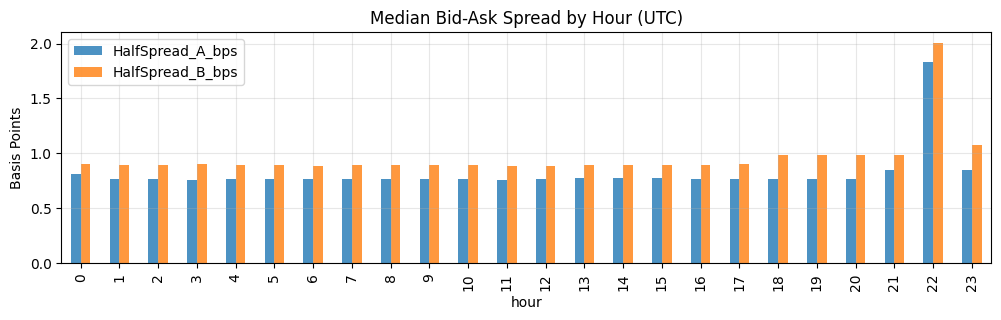


=== RETURN STATISTICS (Log Scale) ===
         Mean (bps)  Vol (bps)      Skew   Kurtosis
AUD/USD   -0.046397   3.802624 -0.522662  10.282642
NZD/USD   -0.037574   3.932509 -0.863125  14.185103

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


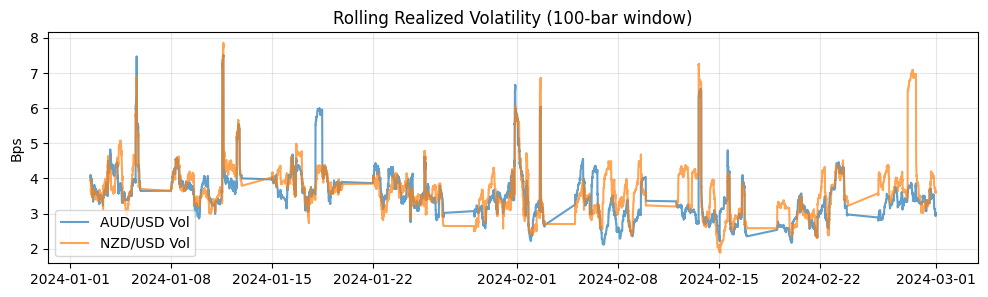

In [ ]:
eda_months = ["202401", "202402"]
eda_files = [
    [f"../data/processed/audusd_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/audusd_dukascopy_bid_{m}.parquet" for m in eda_months],
    [f"../data/processed/nzdusd_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/nzdusd_dukascopy_bid_{m}.parquet" for m in eda_months],
]

# Build 24-hour bars for the EDA
builder_eda = SPREAD(agg_type='volume', threshold=EDA_THRESHOLD, active_hours=(EDA_START_HOUR, EDA_END_HOUR))
df_raw_eda = builder_eda.build(eda_files)

# Run Descriptive Stats
eda = DESCRIPTIVE(df_raw_eda, name_a=NAME_A, name_b=NAME_B)
eda.generate_full_eda()

### DATA

In [25]:
months = [
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/audusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/audusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 50027 rows


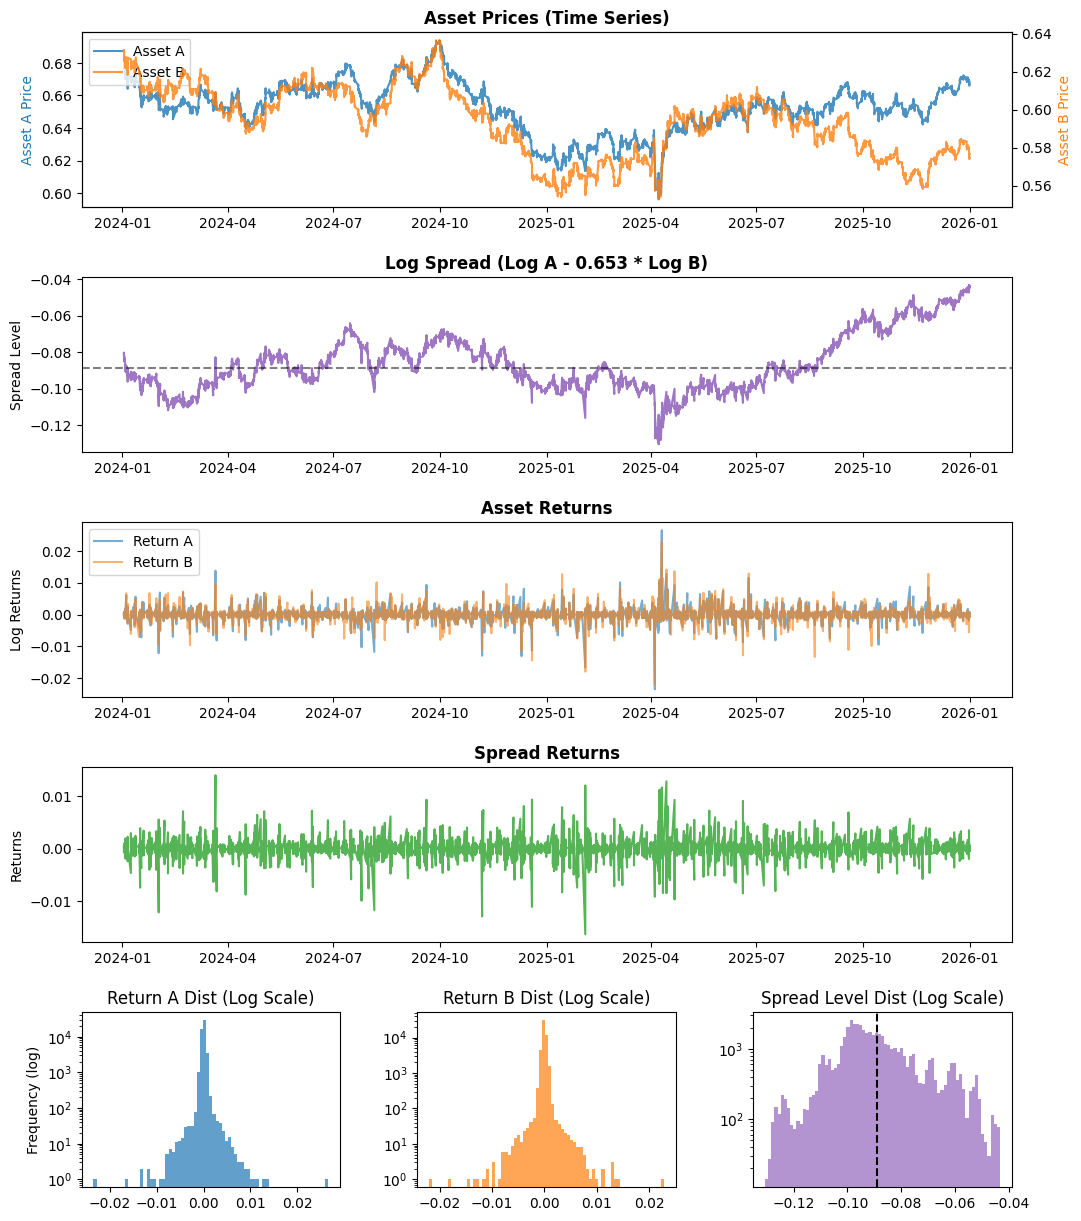

In [ ]:
builder = SPREAD(agg_type='volume', threshold=THRESHOLD, active_hours=(START_HOUR, END_HOUR))
df = builder.build(my_files)
builder.plot_diagnostics()

### DESCRIPTIVE


=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 11:00 to 14:00 UTC
Overall Median Spread: A=0.75 | B=0.87 bps


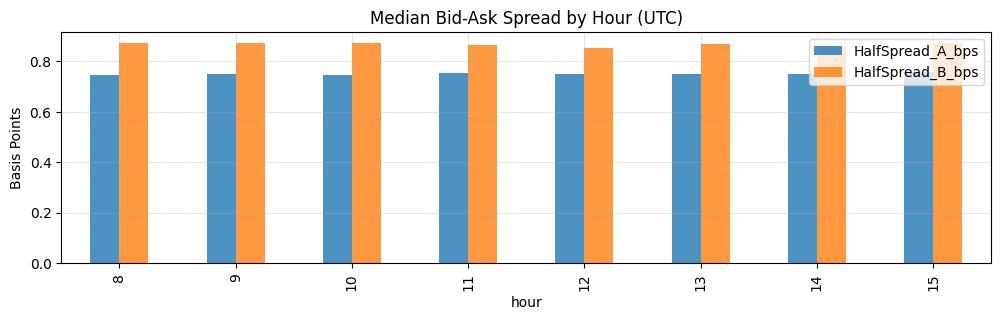


=== RETURN STATISTICS (Log Scale) ===
        Mean (bps)  Vol (bps)      Skew    Kurtosis
AUDUSD   -0.004734   5.846165  0.149936  224.154253
NZDUSD   -0.018571   6.005629 -0.195559  185.364850

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


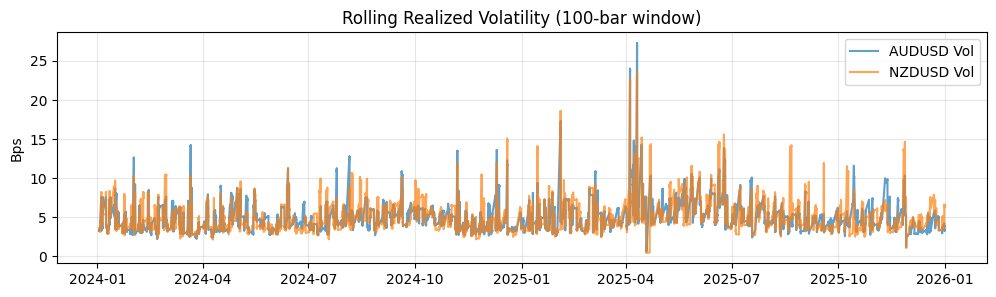

In [ ]:
eda = DESCRIPTIVE(df, name_a=NAME_A, name_b=NAME_B)
eda.generate_full_eda()

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.8808 | half-life=1176.5 | β=0.6527

Rolling (2000-bar, step 200, n=241):
  p<0.05: 6.2% | p<0.10: 12.9%
  half-life: 45.3 (IQR 20–84)
  β: 0.7671 ±0.2896 [-0.1284, 1.3978]


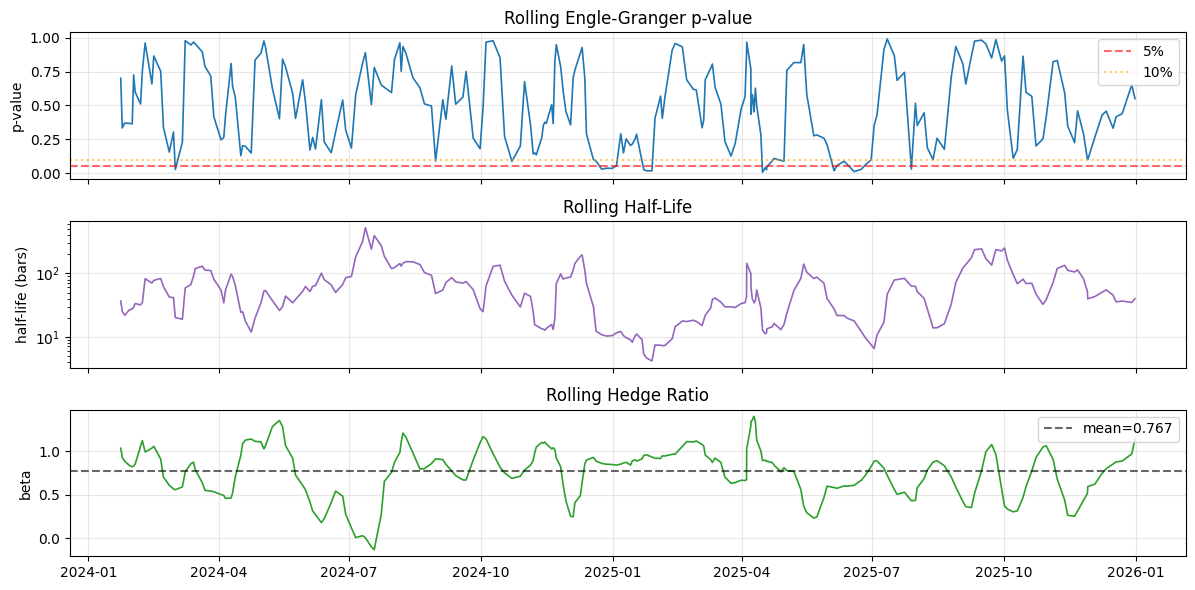

In [ ]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=ROLLING_WINDOW, rolling_step=ROLLING_STEP)

### RELOAD MODULES

In [32]:
import importlib
import engine, backtester, tearsheet, wfo

importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)
importlib.reload(wfo)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from wfo import WFO

### LIVE TRADING

In [30]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df,
    train_days=TRAIN_DAYS,
    coint_window=COINT_WINDOW,
    z_window=Z_WINDOW,
    k_regimes=K_REGIMES,
    winsorize_std=WINSORIZE_STD,
    scaling=SCALING
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 0.4579 | AR: 0.9516
[2024-02-27] Beta: 0.9868 | AR: 0.9532
[2024-03-12] Beta: 1.0933 | AR: 0.9280
[2024-03-26] Beta: 0.9349 | AR: 0.9295
[2024-04-09] Beta: 1.0562 | AR: 0.9271
[2024-04-23] Beta: 0.6488 | AR: 0.9454
[2024-05-07] Beta: 0.8902 | AR: 0.9091
[2024-05-21] Beta: 0.6293 | AR: 0.8882
[2024-06-04] Beta: 0.7159 | AR: 0.9411
[2024-06-18] Beta: 0.8808 | AR: 0.9512
[2024-07-02] Beta: 0.6600 | AR: 0.9672
[2024-07-16] Beta: 0.4219 | AR: 0.9561
[2024-07-30] Beta: 0.7687 | AR: 0.9644
[2024-08-13] Beta: 0.8240 | AR: 0.9751
[2024-08-27] Beta: 0.6855 | AR: 0.9770
[2024-09-10] Beta: 0.9084 | AR: 0.9790
[2024-09-24] Beta: 1.0324 | AR: 0.9503
[2024-10-08] Beta: 0.7086 | AR: 0.9239
[2024-10-22] Beta: 0.7791 | AR: 0.9264
[2024-11-05] Beta: 1.0358 | AR: 0.9499
[2024-11-19] Beta: 0.6208 | AR: 0.9087
[2024-12-03] Beta: 0.9328 | AR: 0.9319
[2024-12-17] Beta: 0.9351 | AR: 0.9473
[2025-01-02] Beta: 0.5841 | AR: 0.9383

### BACKTESTER w/ WFO

In [35]:
from wfo import WFO

wfo = WFO(live_trading_data)
results_wfo = wfo.run_wfo(val_months=VAL_MONTHS, test_months=TEST_MONTHS, n_trials=N_TRIALS)

[I 2026-04-24 09:57:47,547] A new study created in memory with name: no-name-879413cf-c38d-45b3-8958-eb7bb4f34947


Starting WFO: 3mo Validation / 1mo Test...
Tuning for 2024-05-10 to 2024-06-07...


[I 2026-04-24 09:57:49,163] Trial 0 finished with value: -2.1330176143442965 and parameters: {'entry_z': 1.2, 'exit_z': 0.20000000000000007, 'danger_threshold': 0.7, 'ar_limit': 0.89}. Best is trial 0 with value: -2.1330176143442965.
[I 2026-04-24 09:57:49,175] Trial 1 finished with value: 0.088558859955429 and parameters: {'entry_z': 1.3, 'exit_z': -0.09999999999999998, 'danger_threshold': 0.75, 'ar_limit': 0.9099999999999999}. Best is trial 1 with value: 0.088558859955429.
[I 2026-04-24 09:57:49,186] Trial 2 finished with value: 4.199995580605519 and parameters: {'entry_z': 2.0, 'exit_z': 0.0, 'danger_threshold': 0.5, 'ar_limit': 0.89}. Best is trial 2 with value: 4.199995580605519.
[I 2026-04-24 09:57:49,196] Trial 3 finished with value: -99.0 and parameters: {'entry_z': 1.5, 'exit_z': 0.30000000000000004, 'danger_threshold': 0.95, 'ar_limit': 0.87}. Best is trial 2 with value: 4.199995580605519.
[I 2026-04-24 09:57:49,207] Trial 4 finished with value: -0.429760143237895 and paramet

Tuning for 2024-06-10 to 2024-07-08...


[I 2026-04-24 09:57:51,409] Trial 14 finished with value: -0.7326230624667532 and parameters: {'entry_z': 1.6, 'exit_z': 0.4, 'danger_threshold': 0.5, 'ar_limit': 0.89}. Best is trial 3 with value: 16.9256374258698.
[I 2026-04-24 09:57:51,429] Trial 15 finished with value: 15.592273049022547 and parameters: {'entry_z': 1.2, 'exit_z': 0.20000000000000007, 'danger_threshold': 0.7, 'ar_limit': 0.99}. Best is trial 3 with value: 16.9256374258698.
[I 2026-04-24 09:57:51,448] Trial 16 finished with value: 11.883131323197958 and parameters: {'entry_z': 2.0, 'exit_z': 0.5, 'danger_threshold': 0.6, 'ar_limit': 0.96}. Best is trial 3 with value: 16.9256374258698.
[I 2026-04-24 09:57:51,467] Trial 17 finished with value: -99.0 and parameters: {'entry_z': 2.3, 'exit_z': -0.19999999999999996, 'danger_threshold': 0.8500000000000001, 'ar_limit': 0.87}. Best is trial 3 with value: 16.9256374258698.
[I 2026-04-24 09:57:51,486] Trial 18 finished with value: 8.975883843314516 and parameters: {'entry_z': 

...

[I 2026-04-24 09:58:25,796] Trial 13 finished with value: -0.18002843317707723 and parameters: {'entry_z': 2.2, 'exit_z': 0.0, 'danger_threshold': 0.8500000000000001, 'ar_limit': 0.95}. Best is trial 5 with value: 9.498075444038781.
[I 2026-04-24 09:58:25,816] Trial 14 finished with value: -99.0 and parameters: {'entry_z': 2.2, 'exit_z': 0.20000000000000007, 'danger_threshold': 0.7, 'ar_limit': 0.9}. Best is trial 5 with value: 9.498075444038781.
[I 2026-04-24 09:58:25,838] Trial 15 finished with value: 4.452129131428024 and parameters: {'entry_z': 2.4000000000000004, 'exit_z': -0.5, 'danger_threshold': 0.95, 'ar_limit': 0.95}. Best is trial 5 with value: 9.498075444038781.
[I 2026-04-24 09:58:25,857] Trial 16 finished with value: -99.0 and parameters: {'entry_z': 2.3, 'exit_z': -0.09999999999999998, 'danger_threshold': 0.7, 'ar_limit': 0.9}. Best is trial 5 with value: 9.498075444038781.
[I 2026-04-24 09:58:25,876] Trial 17 finished with value: 5.681447836057997 and parameters: {'entr

Tuning for 2025-11-24 to 2025-12-22...


[I 2026-04-24 09:58:27,823] Trial 15 finished with value: -99.0 and parameters: {'entry_z': 1.5, 'exit_z': -0.19999999999999996, 'danger_threshold': 0.9, 'ar_limit': 0.9099999999999999}. Best is trial 2 with value: 8.205230035625997.
[I 2026-04-24 09:58:27,843] Trial 16 finished with value: -99.0 and parameters: {'entry_z': 2.5, 'exit_z': -0.5, 'danger_threshold': 0.65, 'ar_limit': 0.9199999999999999}. Best is trial 2 with value: 8.205230035625997.
[I 2026-04-24 09:58:27,864] Trial 17 finished with value: -1.148505356807973 and parameters: {'entry_z': 2.1, 'exit_z': -0.4, 'danger_threshold': 0.8500000000000001, 'ar_limit': 0.96}. Best is trial 2 with value: 8.205230035625997.
[I 2026-04-24 09:58:27,883] Trial 18 finished with value: 3.0228516148807114 and parameters: {'entry_z': 1.4, 'exit_z': 0.10000000000000009, 'danger_threshold': 0.75, 'ar_limit': 0.99}. Best is trial 2 with value: 8.205230035625997.
[I 2026-04-24 09:58:27,903] Trial 19 finished with value: -99.0 and parameters: {'

Tuning for 2025-12-23 to 2025-12-31...


[I 2026-04-24 09:58:29,804] Trial 15 finished with value: 4.132673002858557 and parameters: {'entry_z': 1.9, 'exit_z': -0.19999999999999996, 'danger_threshold': 0.65, 'ar_limit': 0.97}. Best is trial 14 with value: 6.4910695125945885.
[I 2026-04-24 09:58:29,822] Trial 16 finished with value: -99.0 and parameters: {'entry_z': 1.9, 'exit_z': -0.19999999999999996, 'danger_threshold': 0.65, 'ar_limit': 0.94}. Best is trial 14 with value: 6.4910695125945885.
[I 2026-04-24 09:58:29,842] Trial 17 finished with value: 4.357643137913415 and parameters: {'entry_z': 1.9, 'exit_z': 0.20000000000000007, 'danger_threshold': 0.65, 'ar_limit': 0.97}. Best is trial 14 with value: 6.4910695125945885.
[I 2026-04-24 09:58:29,860] Trial 18 finished with value: -99.0 and parameters: {'entry_z': 1.9, 'exit_z': 0.30000000000000004, 'danger_threshold': 0.6, 'ar_limit': 0.9199999999999999}. Best is trial 14 with value: 6.4910695125945885.
[I 2026-04-24 09:58:29,878] Trial 19 finished with value: 2.0266995714584

### TEARSHEET


                      QUANTITATIVE STRATEGY TEARSHEET                      
Metric                         | Baseline     | AR           | MS_AR        |
-----------------------------------------------------------------------------

--- FINANCIAL METRICS ---
Total Return (bps)             | 6741.93      | 5920.78      | 3032.82      |
Annual Return (bps)            | 3988.18      | 3502.43      | 1794.06      |
Annual Volatility (bps)        | 749.38       | 703.40       | 621.78       |
Max Drawdown (bps)             | -329.26      | -329.26      | -333.34      |
Sharpe Ratio                   | 5.32         | 4.98         | 2.89         |
Sortino Ratio                  | 6.46         | 5.76         | 2.96         |
Calmar Ratio                   | 12.11        | 10.64        | 5.38         |
Gross Profit (bps)             | 45364.92     | 39320.77     | 34868.61     |
Gross Loss (bps)               | 38622.99     | 33399.99     | 31835.79     |
Profit Factor                  | 1.17 

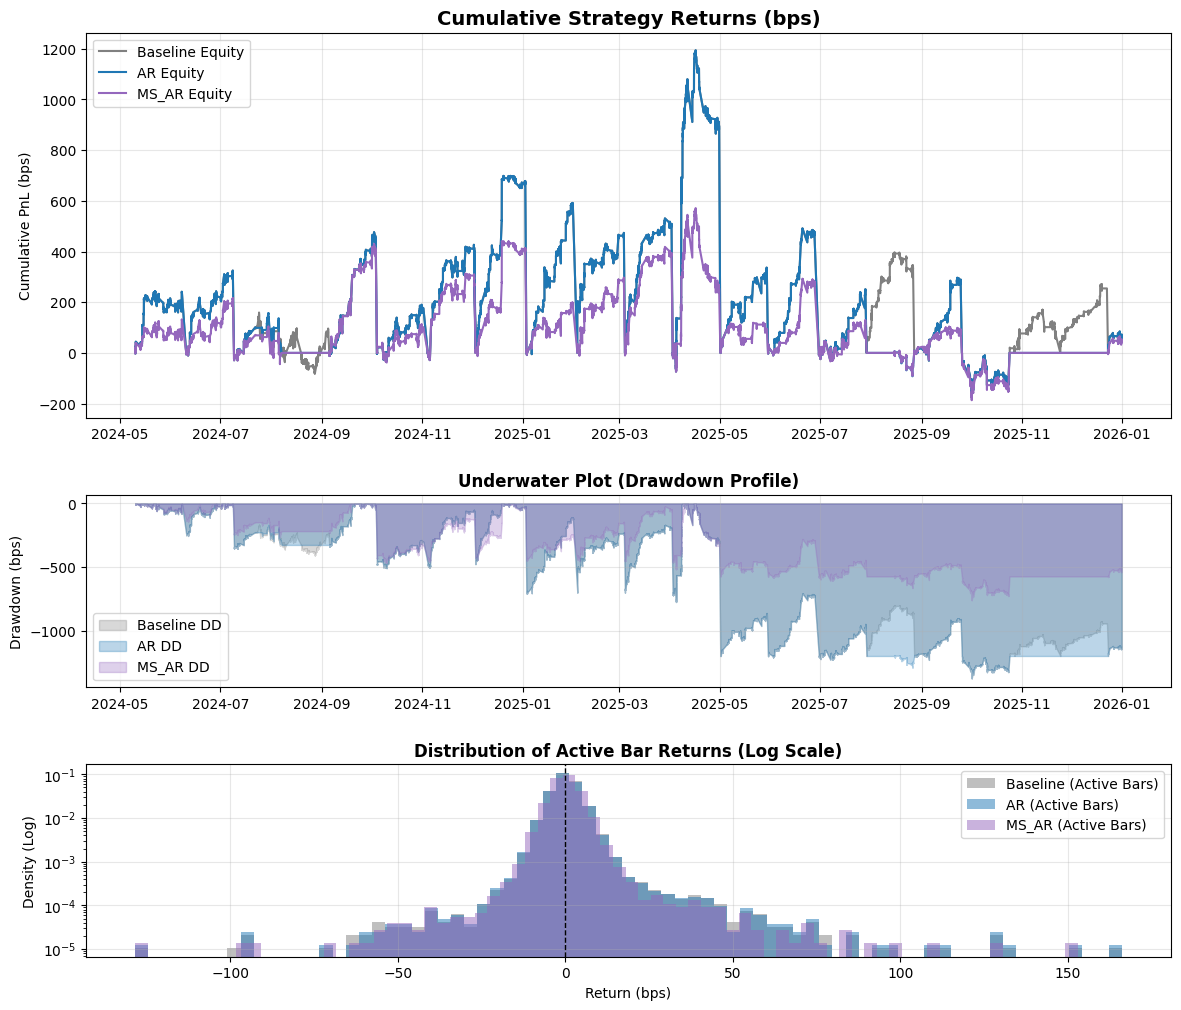

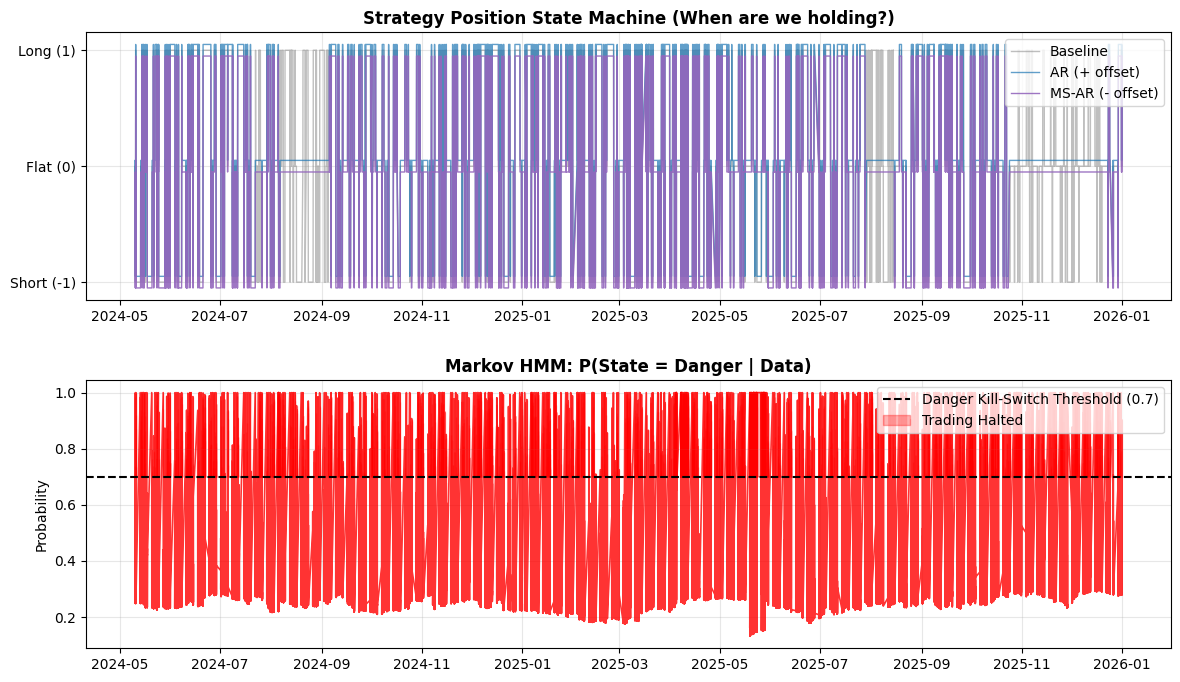

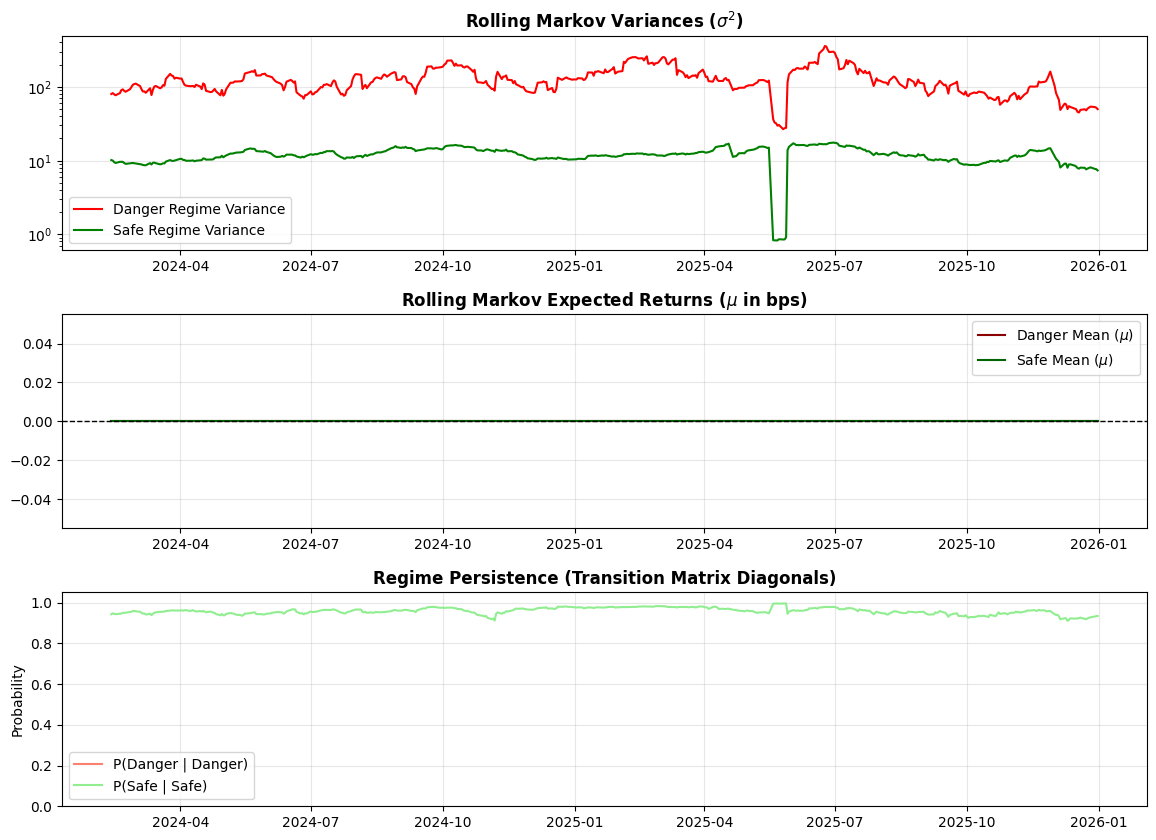

In [36]:
ts = TEARSHEET(results_wfo, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()